# Unroll Test On Aube Regular Mesh

Notebook minimal pour evaluer un checkpoint sur la crue test `Q30` du maillage regulier Aube.

Flux :
- charger le dataset regulier de test
- reutiliser les statistiques du checkpoint
- evaluer l'unrolling sur toute la crue `Q30`
- afficher la moyenne de l'erreur absolue sur `h`
- visualiser `GT / Pred / |Err|` a trois temps


In [1]:
import pickle
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch


def find_project_root(start: Path) -> Path:
    for path in [start.resolve(), *start.resolve().parents]:
        if (path / "python" / "create_dgl_dataset.py").exists():
            return path
    raise RuntimeError("Cannot find gnn_modulus_test project root.")


PROJECT_ROOT = find_project_root(Path.cwd())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from python.create_dgl_dataset import TelemacDataset, TelemacDatasetWithQ
from python.eval_rollout import (
    build_model,
    build_rollout_context,
    create_rollout_state,
    denormalize_state,
    load_model_checkpoint,
    rollout_step,
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)


device: cuda


In [2]:
MODEL_CONFIG = {
    "name": "aube_regular_from_scratch",
    "ckpt_dir": "/work/m24046/m24046mrcr/Test_Aube_regular/checkpoints/config_transfer_Aube_regular/Seed0/",
    "epoch": 1900,
    "use_q_feature": True,
    "mesh": "aube_regular",
    "num_input_features": 10,
    "num_output_features": 3,
    "num_edge_features": 3,
    "mp_layers": 10,
    "do_concat_trick": True,
    "num_processor_checkpoint_segments": 0,
    "dt_seconds": 1800.0,
}

REGULAR_BASE_BIN = "/work/m24046/m24046mrcr/Test_Aube_regular/dataset_50m/regular_50_dataset_base.bin"
REGULAR_DYNAMIC_FILE = "/work/m24046/m24046mrcr/Test_Aube_regular/dataset_50m/regular_50_dataset_T2V6_Q100_0_0-92.pkl"
HYDRO_FILE = "/work/m24046/m24046mrcr/Test_Aube_regular/liqu/T2_Q100_V1.liq"
REGULAR_MESH_SLF = "/work/m24046/m24046mrcr/Test_Aube_regular/Aube_regular_50m.slf"

REQUESTED_MAX_HOURS = 90
FIGSIZE = (7, 4)
DT_SECONDS = MODEL_CONFIG["dt_seconds"]
HOUR_IN_STEPS = max(1, int(round(3600.0 / DT_SECONDS)))

START_HOURS = 0
START_STEP = int(round(START_HOURS * 3600.0 / DT_SECONDS))


In [3]:
def require_existing(path_like, label):
    path = Path(path_like).expanduser()
    if not path.exists():
        raise FileNotFoundError(f"{label} introuvable: {path}")
    return path


def get_dynamic_length(file_path):
    with open(file_path, "rb") as f:
        return len(pickle.load(f))
    
def slice_dynamic_file(file_path, start_step):
    with open(file_path, "rb") as f:
        dynamic_data = pickle.load(f)

    if start_step <= 0:
        return Path(file_path), len(dynamic_data)

    shifted_data = dynamic_data[start_step:]
    if len(shifted_data) < 2:
        raise ValueError(
            f"Pas assez de points apres start_step={start_step}. "
            f"len={len(dynamic_data)}"
        )

    shifted_path = Path("/tmp") / f"{Path(file_path).stem}_from_{start_step}{Path(file_path).suffix}"
    with open(shifted_path, "wb") as f:
        pickle.dump(shifted_data, f)

    return shifted_path, len(shifted_data)

def build_dataset(sequence_length, overlap=1):
    base_kwargs = {
        "data_dir": str(regular_base_path),
        "dynamic_data_files": [str(dynamic_file)],
        "split": "test",
        "ckpt_path": str(ckpt_dir),
        "normalize": True,
        "sequence_length": sequence_length,
        "overlap": overlap,
    }

    if MODEL_CONFIG["use_q_feature"]:
        return TelemacDatasetWithQ(
            name="aube_regular_test_q",
            hydro_data_files=[str(hydro_file)],
            dt_seconds=DT_SECONDS,
            **base_kwargs,
        )

    return TelemacDataset(name="aube_regular_test", **base_kwargs)

regular_base_path = require_existing(REGULAR_BASE_BIN, "REGULAR_BASE_BIN")
ckpt_dir = require_existing(MODEL_CONFIG["ckpt_dir"], "CKPT_DIR")
raw_dynamic_file = require_existing(REGULAR_DYNAMIC_FILE, "REGULAR_DYNAMIC_FILE")

hydro_file = None
if MODEL_CONFIG["use_q_feature"]:
    hydro_file = require_existing(HYDRO_FILE, "HYDRO_FILE")

dynamic_file, num_samples = slice_dynamic_file(raw_dynamic_file, START_STEP)
    
    
num_samples = get_dynamic_length(dynamic_file)
max_available_step = max(1, num_samples - 1)
available_max_hours = max_available_step // HOUR_IN_STEPS

if available_max_hours < 1:
    raise ValueError("Aucun horizon horaire disponible avec le fichier dynamique courant.")

if available_max_hours < REQUESTED_MAX_HOURS:
    print(
        f"Attention: le fichier test ne contient que {num_samples} echantillons. "
        f"Le notebook evaluera donc {available_max_hours} heures au lieu de {REQUESTED_MAX_HOURS}."
    )

MAX_HOURS = min(REQUESTED_MAX_HOURS, available_max_hours)
HORIZONS_STEPS = [h * HOUR_IN_STEPS for h in range(1, MAX_HOURS + 1)]
SEQUENCE_LENGTH = max(HORIZONS_STEPS) + 1

print("model:", MODEL_CONFIG["name"])
print("ckpt dir:", ckpt_dir)
print("normalization:", 'split="test" + ckpt_path=checkpoint')
print("use_q_feature:", MODEL_CONFIG["use_q_feature"])
print("regular base:", regular_base_path)
print("dynamic file:", dynamic_file)
print("hydro file:", hydro_file)
print("num_samples:", num_samples)
print("max_hours:", MAX_HOURS)
print("sequence_length:", SEQUENCE_LENGTH)


Attention: le fichier test ne contient que 92 echantillons. Le notebook evaluera donc 45 heures au lieu de 90.
model: aube_regular_from_scratch
ckpt dir: /work/m24046/m24046mrcr/Test_Aube_regular/checkpoints/config_transfer_Aube_regular/Seed0
normalization: split="test" + ckpt_path=checkpoint
use_q_feature: True
regular base: /work/m24046/m24046mrcr/Test_Aube_regular/dataset_50m/regular_50_dataset_base.bin
dynamic file: /work/m24046/m24046mrcr/Test_Aube_regular/dataset_50m/regular_50_dataset_T2V6_Q100_0_0-92.pkl
hydro file: /work/m24046/m24046mrcr/Test_Aube_regular/liqu/T2_Q100_V1.liq
num_samples: 92
max_hours: 45
sequence_length: 91


In [4]:
dataset = build_dataset(sequence_length=SEQUENCE_LENGTH, overlap=1)
expected_input_features = dataset.base_graph.ndata["static"].shape[1] + (4 if MODEL_CONFIG["use_q_feature"] else 3)
if MODEL_CONFIG["num_input_features"] != expected_input_features:
    raise ValueError(
        f"num_input_features={MODEL_CONFIG['num_input_features']} incompatible avec le dataset ({expected_input_features})."
    )

model = build_model(
    num_input_features=MODEL_CONFIG["num_input_features"],
    num_edge_features=MODEL_CONFIG["num_edge_features"],
    num_output_features=MODEL_CONFIG["num_output_features"],
    mp_layers=MODEL_CONFIG["mp_layers"],
    do_concat_trick=MODEL_CONFIG["do_concat_trick"],
    num_processor_checkpoint_segments=MODEL_CONFIG["num_processor_checkpoint_segments"],
)
model = load_model_checkpoint(model, str(ckpt_dir), MODEL_CONFIG["epoch"], device)
context = build_rollout_context(dataset, device, MODEL_CONFIG["use_q_feature"])

print("dataset sequences:", len(dataset))
print("expected input features:", expected_input_features)
print("loaded checkpoint epoch:", MODEL_CONFIG["epoch"])


[09:57:11 - checkpoint - INFO] Loaded model state dictionary /work/m24046/m24046mrcr/Test_Aube_regular/checkpoints/config_transfer_Aube_regular/Seed0/MeshGraphNet.0.1900.mdlus to device cuda


Loading normalization statistics...


[09:57:11 - checkpoint - INFO] Loaded checkpoint file /work/m24046/m24046mrcr/Test_Aube_regular/checkpoints/config_transfer_Aube_regular/Seed0/checkpoint.0.1900.pt to device cuda


dataset sequences: 1
expected input features: 10
loaded checkpoint epoch: 1900


In [5]:
def summarize_l1_h(agg, horizons_steps):
    rows = []
    for step in horizons_steps:
        if len(agg[step]) == 0:
            continue

        values = np.asarray(agg[step], dtype=float)
        rows.append(
            {
                "step": step,
                "hours": step * DT_SECONDS / 3600.0,
                "l1_mean_h": float(np.nanmean(values)),
                "l1_std_h": float(np.nanstd(values)),
                "count": int(values.size),
            }
        )
    return rows


def evaluate_dataset_h(model, ds, context, horizons_steps):
    agg = {step: [] for step in horizons_steps}
    step_set = set(horizons_steps)
    max_h = max(horizons_steps)

    for idx in range(len(ds)):
        graphs = ds[idx]
        if len(graphs) <= max_h:
            continue

        state = create_rollout_state(graphs[0], context)

        for t in range(max_h):
            x_gt_full_n = graphs[t + 1].ndata["x"][:, context.dyn_start:context.dyn_start + context.dyn_len].to(context.device)
            x_gt = denormalize_state(x_gt_full_n[:, :3], context)
            q_t1_n = x_gt_full_n[:, 3:4] if MODEL_CONFIG["use_q_feature"] else None

            result = rollout_step(
                model=model,
                state=state,
                context=context,
                x_gt=x_gt,
                q_t1_n=q_t1_n,
            )

            step = t + 1
            if step in step_set:
                l1_h = torch.mean(torch.abs(result.predicted_state[:, 0] - result.target_state[:, 0]))
                agg[step].append(float(l1_h.detach().cpu().item()))

            state = result.next_state

    return summarize_l1_h(agg, horizons_steps)


rows = evaluate_dataset_h(
    model=model,
    ds=dataset,
    context=context,
    horizons_steps=HORIZONS_STEPS,
)

if not rows:
    raise ValueError("Aucune statistique calculee. Verifie sequence_length et le fichier dynamique.")

for row in rows:
    print(row)


{'step': 2, 'hours': 1.0, 'l1_mean_h': 0.02662103995680809, 'l1_std_h': 0.0, 'count': 1}
{'step': 4, 'hours': 2.0, 'l1_mean_h': 0.022844355553388596, 'l1_std_h': 0.0, 'count': 1}
{'step': 6, 'hours': 3.0, 'l1_mean_h': 0.03005007840692997, 'l1_std_h': 0.0, 'count': 1}
{'step': 8, 'hours': 4.0, 'l1_mean_h': 0.03453292325139046, 'l1_std_h': 0.0, 'count': 1}
{'step': 10, 'hours': 5.0, 'l1_mean_h': 0.038988713175058365, 'l1_std_h': 0.0, 'count': 1}
{'step': 12, 'hours': 6.0, 'l1_mean_h': 0.04388964921236038, 'l1_std_h': 0.0, 'count': 1}
{'step': 14, 'hours': 7.0, 'l1_mean_h': 0.04789978638291359, 'l1_std_h': 0.0, 'count': 1}
{'step': 16, 'hours': 8.0, 'l1_mean_h': 0.05296105518937111, 'l1_std_h': 0.0, 'count': 1}
{'step': 18, 'hours': 9.0, 'l1_mean_h': 0.0585249625146389, 'l1_std_h': 0.0, 'count': 1}
{'step': 20, 'hours': 10.0, 'l1_mean_h': 0.06418520957231522, 'l1_std_h': 0.0, 'count': 1}
{'step': 22, 'hours': 11.0, 'l1_mean_h': 0.07003548741340637, 'l1_std_h': 0.0, 'count': 1}
{'step': 24

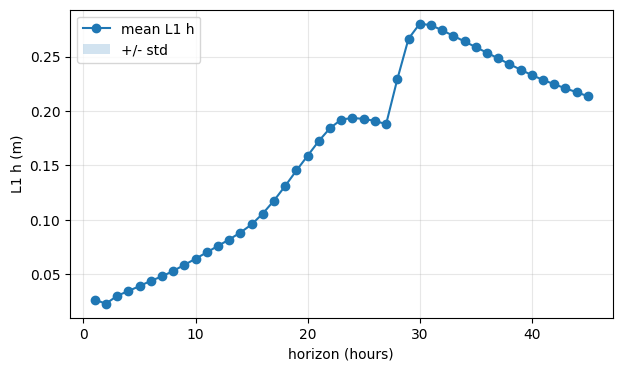

In [6]:
hours = [row["hours"] for row in rows]
mean_h = [row["l1_mean_h"] for row in rows]
std_h = [row["l1_std_h"] for row in rows]

lower = np.asarray(mean_h) - np.asarray(std_h)
upper = np.asarray(mean_h) + np.asarray(std_h)

plt.figure(figsize=FIGSIZE)
plt.plot(hours, mean_h, marker="o", label="mean L1 h")
plt.fill_between(hours, lower, upper, alpha=0.2, label="+/- std")
plt.xlabel("horizon (hours)")
plt.ylabel("L1 h (m)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


In [7]:
import matplotlib.tri as mtri

from python.create_dgl_dataset import add_mesh_info
from python.python_code.data_manip.extraction.telemac_file import TelemacFile


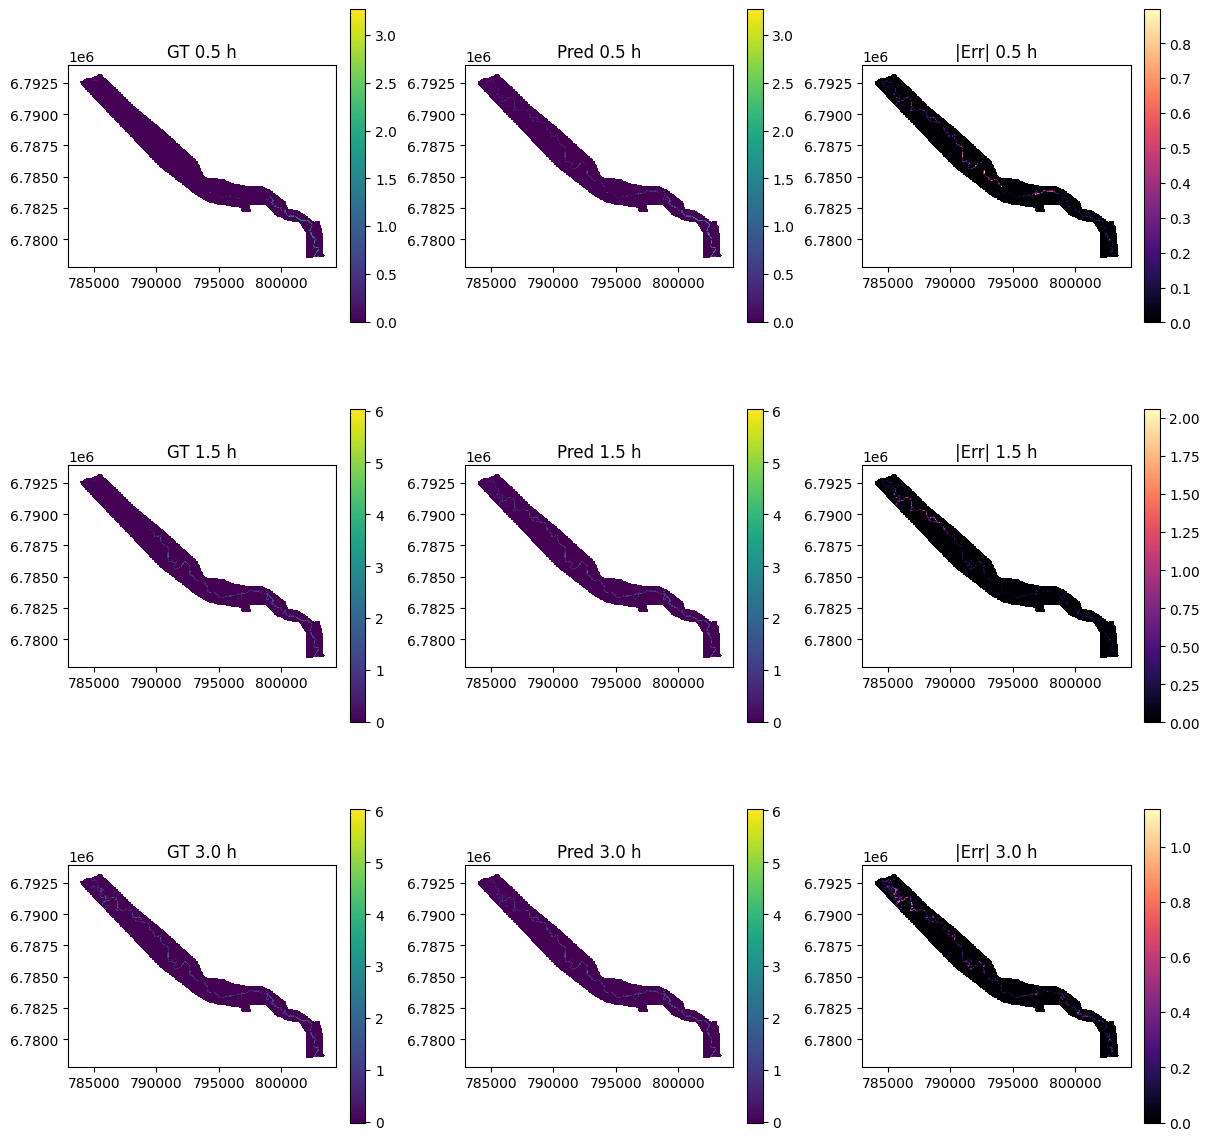

In [8]:
SEQUENCE_INDEX = 0

mesh = TelemacFile(REGULAR_MESH_SLF)
xy, triangles = add_mesh_info(mesh)
triangulation = mtri.Triangulation(xy[:, 0], xy[:, 1], triangles)

graphs = dataset[SEQUENCE_INDEX]
steps_to_plot = [1, 3,6]

state = create_rollout_state(graphs[0], context)
snapshots = {}

for step in range(1, max(steps_to_plot) + 1):
    x_gt_full_n = graphs[step].ndata["x"][:, context.dyn_start:context.dyn_start + context.dyn_len].to(context.device)
    x_gt = denormalize_state(x_gt_full_n[:, :3], context)
    q_t1_n = x_gt_full_n[:, 3:4] if MODEL_CONFIG["use_q_feature"] else None

    result = rollout_step(
        model=model,
        state=state,
        context=context,
        x_gt=x_gt,
        q_t1_n=q_t1_n,
    )

    if step in steps_to_plot:
        snapshots[step] = {
            "gt_h": result.target_state[:, 0].detach().cpu().numpy(),
            "pred_h": result.predicted_state[:, 0].detach().cpu().numpy(),
        }

    state = result.next_state

fig, axes = plt.subplots(3, 3, figsize=(12, 12), constrained_layout=True)

for row, step in enumerate(steps_to_plot):
    gt_h = snapshots[step]["gt_h"]
    pred_h = snapshots[step]["pred_h"]
    err_h = np.abs(pred_h - gt_h)

    vmin = float(min(gt_h.min(), pred_h.min()))
    vmax = float(max(gt_h.max(), pred_h.max()))
    hours = step * MODEL_CONFIG["dt_seconds"] / 3600.0

    plots = [
        (f"GT {hours:.1f} h", gt_h, "viridis", vmin, vmax),
        (f"Pred {hours:.1f} h", pred_h, "viridis", vmin, vmax),
        (f"|Err| {hours:.1f} h", err_h, "magma", None, None),
    ]

    for col, (title, values, cmap, pmin, pmax) in enumerate(plots):
        artist = axes[row, col].tripcolor(
            triangulation,
            values,
            shading="flat",
            cmap=cmap,
            vmin=pmin,
            vmax=pmax,
        )
        axes[row, col].set_title(title)
        axes[row, col].set_aspect("equal")
        fig.colorbar(artist, ax=axes[row, col], shrink=0.8)

plt.show()
